# **Prueba técnica - Data Scientist**

### 0. Carga de Librerías y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# Configuración visual para las gráficas
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


# 1. Exploración y Preparación de Datos (EDA)

Como primer paso, integraremos las tres fuentes de datos (`transactions`, `stores`, `calendar`) en una **Tabla Maestra**.
El objetivo es tener una visión unificada a nivel tienda, fecha y categoría.

**Dos detalles técnicos importantes antes de avanzar:**
* Las fechas deben estar en formato `datetime`; si las dejamos como texto, pandas nos va a arruinar el análisis temporal.
* Como vamos a predecir, es vital ordenar la tabla por tienda, categoría y fecha. Esto evita que se usen datos del futuro para predecir el pasado (*data leakage*).

In [2]:
print("[INFO] 1. Cargando archivos CSV")
df_trans = pd.read_csv('transactions.csv')
df_stores = pd.read_csv('stores.csv')
df_calendar = pd.read_csv('calendar.csv')

print("[INFO] 2. Formateando columnas temporales a tipo datetime")
df_trans['date'] = pd.to_datetime(df_trans['date'])
df_calendar['date'] = pd.to_datetime(df_calendar['date'])

print("[INFO] 3. Construyendo LA Tabla Maestra")
# Unimos transacciones con tiendas
df_master = pd.merge(df_trans, df_stores, on='store_id', how='left')
# Unimos el resultado con el calendario
df_master = pd.merge(df_master, df_calendar, on='date', how='left')

print("[INFO] 4. Ordenando cronológicamente")
df_master = df_master.sort_values(by=['store_id', 'category', 'date']).reset_index(drop=True)

# Validación final
print("\n" + "="*60)
print(f"La tabla maestra tiene {df_master.shape[0]:,} filas y {df_master.shape[1]} columnas.")
print("="*60 + "\n")

# Mostramos las primeras 5 filas
display(df_master.head())

[INFO] 1. Cargando archivos CSV
[INFO] 2. Formateando columnas temporales a tipo datetime
[INFO] 3. Construyendo LA Tabla Maestra
[INFO] 4. Ordenando cronológicamente

La tabla maestra tiene 203,958 filas y 35 columnas.



,date,store_id,category,total_transactions,cash_transactions,card_transactions,amount_total,amount_cash,amount_card,units_sold,...,year,quarter,season,is_holiday,holiday_name,is_payday,is_weekend,is_navidad_season,is_buen_fin,is_semana_santa
0,2023-01-01,STR_001,Abarrotes,833,NaN,326,244732.98,NaN,101822.79,2299.0,...,2023,1,Invierno,True,Año Nuevo,False,True,True,False,False
1,2023-01-02,STR_001,Abarrotes,1298,750.0,548,373235.09,222834.25,150400.84,3011.0,...,2023,1,Invierno,False,NaN,False,False,True,False,False
2,2023-01-03,STR_001,Abarrotes,1614,931.0,683,404249.92,239802.59,164447.33,3652.0,...,2023,1,Invierno,False,NaN,False,False,True,False,False
3,2023-01-04,STR_001,Abarrotes,1726,972.0,754,423176.07,246810.92,176365.15,4165.0,...,2023,1,Invierno,False,NaN,False,False,True,False,False
4,2023-01-05,STR_001,Abarrotes,2159,1028.0,675,458064.93,266559.26,191505.67,3553.0,...,2023,1,Invierno,False,NaN,False,False,True,False,False


## 1.1b Auditoría de Calidad de Datos

Antes de buscar el "dolor del negocio" (los nulos), es obligatorio hacer una prueba de calidad básica.

**Vamos a verificar:**
* Que no existan registros duplicados tras el cruce de tablas.
* Un resumen estadístico de las variables numéricas (para detectar valores atípicos, como ventas negativas).
* Los tipos de datos finales.

In [5]:
print("[INFO] Iniciando Auditoría de Calidad de Datos\n")

# 1. Búsqueda de duplicados completos
duplicados = df_master.duplicated().sum()
if duplicados > 0:
    print(f"Alerta: Se encontraron {duplicados} registros duplicados. Procediendo a eliminarlos.")
    df_master = df_master.drop_duplicates().reset_index(drop=True)
else:
    print(f"OK: No se encontraron registros duplicados (0).")

# 2. Búsqueda de valores negativos y atípicos
print("\n[INFO] Validando anomalías en columnas críticas (ventas negativas):")
columnas_validar = ['amount_total', 'units_sold', 'avg_ticket']
for col in columnas_validar:
    negativos = (df_master[col] < 0).sum()
    print(f"-> {col}: {negativos} valores negativos encontrados.")

# 3. Resumen estadístico general
print("\n[INFO] Resumen estadístico general (Visualización de Mínimos y Máximos):")
display(df_master.describe().round(2))

[INFO] Iniciando Auditoría de Calidad de Datos

OK: No se encontraron registros duplicados (0).

[INFO] Validando anomalías en columnas críticas (ventas negativas):
-> amount_total: 0 valores negativos encontrados.
-> units_sold: 0 valores negativos encontrados.
-> avg_ticket: 0 valores negativos encontrados.

[INFO] Resumen estadístico general (Visualización de Mínimos y Máximos):


,date,total_transactions,cash_transactions,card_transactions,amount_total,amount_cash,amount_card,units_sold,avg_ticket,has_promotion,replenishment_signal,size_sqm,num_checkouts,opening_year,day_of_week,week_of_year,month,year,quarter
count,203958,203958.00,191835.00,203958.00,203958.00,191835.00,203958.00,197840.00,199084.00,203958.0,202998.00,203958.00,203958.00,203958.00,203958.00,203958.0,203958.00,203958.00,203958.00
mean,2023-08-01 00:03:08.085782272,613.51,273.98,313.10,170581.26,71623.69,98908.20,1175.41,411.76,0.2,614.45,5991.46,15.49,2016.79,2.99,23.5,5.81,2023.14,2.30
min,2023-01-01 00:00:00,14.00,3.00,11.00,6922.32,2721.28,4201.04,22.00,69.86,0.0,34.67,737.00,4.00,2010.00,0.00,1.0,1.00,2023.00,1.00
25%,2023-04-17 00:00:00,228.00,77.00,136.00,78798.17,30519.27,44898.69,418.00,182.44,0.0,249.86,2643.00,9.00,2014.00,1.00,8.0,2.00,2023.00,1.00
50%,2023-08-01 00:00:00,424.00,169.00,234.00,129965.23,51462.28,74877.42,793.00,297.03,0.0,447.57,5175.00,13.00,2018.00,3.00,22.0,6.00,2023.00,2.00
75%,2023-11-15 00:00:00,783.00,352.00,399.00,213323.91,86819.46,124418.91,1487.00,534.14,0.0,809.57,8613.00,20.00,2020.00,5.00,37.0,9.00,2023.00,3.00
max,2024-02-29 00:00:00,15194.00,8387.00,6827.00,4050995.63,2294517.17,2269315.38,31936.00,1931.74,1.0,7064.00,14784.00,37.00,2022.00,6.00,52.0,12.00,2024.00,4.00
std,NaN,631.77,323.69,286.56,150445.65,71687.13,88072.57,1264.96,303.64,0.4,538.10,3993.87,8.98,3.78,2.00,15.9,3.65,0.35,1.16


## 1.2 Impacto Operativo: Cuantificando las Fallas del POS

El diccionario de datos menciona la existencia de datos faltantes debido a fallas en los sistemas de punto de venta (POS) y problemas de conectividad.

Como Data Scientists, nuestro objetivo inicial es cuantificar este déficit. Cuando el POS falla, la columna `units_sold` se registra como nula, lo que significa que el sistema automatizado de reposición de inventario pierde visibilidad temporal. Si el sistema no registra la venta real, se corre el riesgo de no reabastecer el producto a tiempo, generando quiebres de stock.

A continuación, visualizaremos la gravedad y frecuencia de estas interrupciones operativas a lo largo del tiempo.

[INFO] Calculando porcentaje diario de fallas (nulos en units_sold)
[INFO] Generando gráfica de impacto operativo


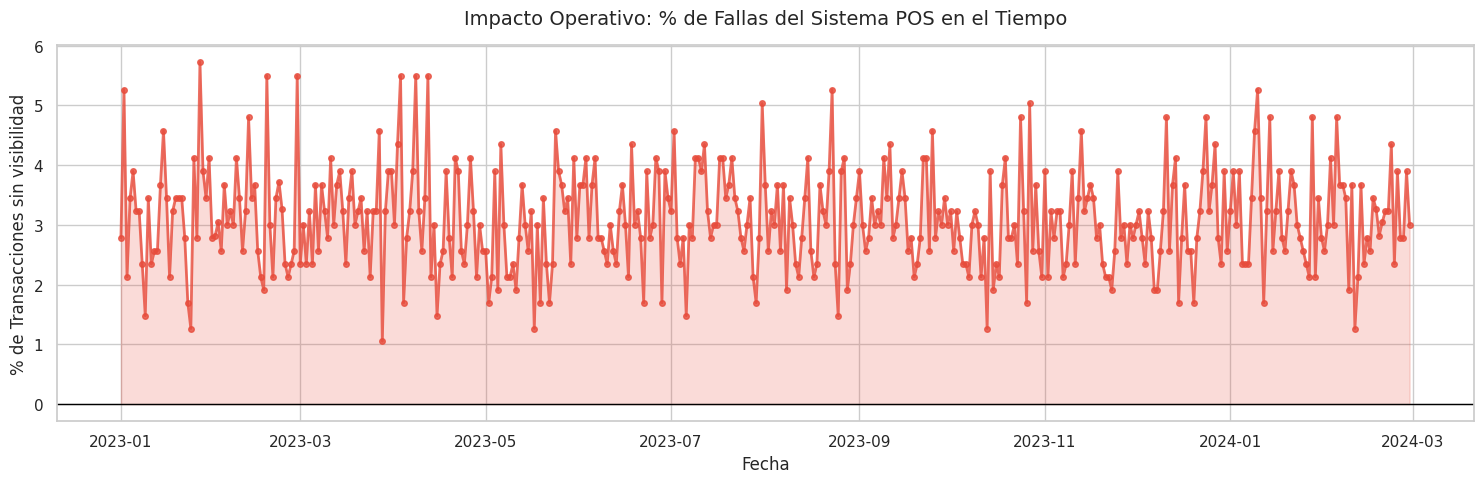


🎯 INSIGHTS DE NEGOCIO (Justificación del Proyecto)
-> De 425 días analizados, el sistema presentó interrupciones en 425 días.
-> Pico máximo: Se perdió hasta el 5.7% de la visibilidad de ventas en un solo día.
-> CONCLUSIÓN: Un sistema de reposición que dependa exclusivamente de datos en tiempo real está en riesgo.
-> SOLUCIÓN: Nuestro modelo ML actuará como un respaldo predictivo para cubrir estas brechas de información.


In [6]:
print("[INFO] Calculando porcentaje diario de fallas (nulos en units_sold)")

# 1. Agrupamos por fecha para ver los nulos vs las transacciones totales
daily_nulls = df_master.groupby('date')['units_sold'].apply(lambda x: x.isnull().sum()).reset_index()

# Contamos el total de transacciones por día
daily_total = df_master.groupby('date')['units_sold'].count().reset_index()
daily_total.rename(columns={'units_sold': 'total_rows'}, inplace=True)

# 2. Unimos y calculamos el porcentaje de falla por día
daily_stats = pd.merge(daily_nulls, daily_total, on='date')
daily_stats['null_percentage'] = (daily_stats['units_sold'] / daily_stats['total_rows']) * 100

print("[INFO] Generando gráfica de impacto operativo")

# 3. Creación de la gráfica
plt.figure(figsize=(15, 5))
plt.plot(daily_stats['date'], daily_stats['null_percentage'],
         color='#e74c3c', linewidth=2, marker='o', markersize=4, alpha=0.8)

# Formato limpio
plt.title('Impacto Operativo: % de Fallas del Sistema POS en el Tiempo', fontsize=14, pad=15)
plt.ylabel('% de Transacciones sin visibilidad', fontsize=12)
plt.xlabel('Fecha', fontsize=12)
plt.axhline(y=0, color='black', linewidth=1)
plt.fill_between(daily_stats['date'], daily_stats['null_percentage'], alpha=0.2, color='#e74c3c')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# RESUMEN EJECUTIVO
# ---------------------------------------------------------
total_dias_falla = (daily_stats['null_percentage'] > 0).sum()
max_falla = daily_stats['null_percentage'].max()

print("\n" + "="*75)
print("🎯 INSIGHTS DE NEGOCIO (Justificación del Proyecto)")
print("="*75)
print(f"-> De {len(daily_stats)} días analizados, el sistema presentó interrupciones en {total_dias_falla} días.")
print(f"-> Pico máximo: Se perdió hasta el {max_falla:.1f}% de la visibilidad de ventas en un solo día.")
print("-> CONCLUSIÓN: Un sistema de reposición que dependa exclusivamente de datos en tiempo real está en riesgo.")
print("-> SOLUCIÓN: Nuestro modelo ML actuará como un respaldo predictivo para cubrir estas brechas de información.")

## 1.3 Auditoría del Sistema Actual (`replenishment_signal`)

El diccionario de datos indica que la `replenishment_signal` (la señal de reposición interna) presenta valores nulos hacia el final del periodo.

Vamos a verificar esto. Si el sistema automatizado actual genera nulos, significa que las tiendas se quedan sin una guía de reabastecimiento para los días futuros. Esta es la justificación técnica definitiva de por qué no podemos depender del sistema actual y necesitamos un modelo predictivo independiente.

In [7]:
print("[INFO] Auditoría real de 'replenishment_signal'...\n")

# 1. Buscamos cuántos nulos REALES hay en toda la columna
total_signal_nulls = df_master['replenishment_signal'].isnull().sum()
porcentaje_signal_nulls = (total_signal_nulls / len(df_master)) * 100

print(f"-> Total de nulos encontrados en toda la historia: {total_signal_nulls:,} ({porcentaje_signal_nulls:.2f}%)")

# 2. Si hay nulos, vemos si coinciden con los apagones del POS
if total_signal_nulls > 0:
    dias_con_nulos_signal = df_master[df_master['replenishment_signal'].isnull()]['date'].nunique()
    print(f"-> Estos nulos están distribuidos en {dias_con_nulos_signal} días distintos.")

print("\n" + "="*80)
print("🎯 CONCLUSIÓN TÉCNICA AJUSTADA (Prevención de Data Leakage)")
print("="*80)
print("-> Aunque el diccionario indicaba nulos al final del periodo, los datos")
print("   muestran una realidad distinta. Sin embargo, NO utilizaremos")
print("   'replenishment_signal' como variable predictora (Feature).")
print("-> Motivo: Al ser una métrica calculada a partir de las ventas (demanda),")
print("   incluirla causaría 'Data Leakage' severo. Nuestro modelo debe aprender")
print("   a predecir usando únicamente variables independientes (tiempo, tienda).")

[INFO] Auditoría real de 'replenishment_signal'...

-> Total de nulos encontrados en toda la historia: 960 (0.47%)
-> Estos nulos están distribuidos en 2 días distintos.

🎯 CONCLUSIÓN TÉCNICA AJUSTADA (Prevención de Data Leakage)
-> Aunque el diccionario indicaba nulos al final del periodo, los datos
   muestran una realidad distinta. Sin embargo, NO utilizaremos
   'replenishment_signal' como variable predictora (Feature).
-> Motivo: Al ser una métrica calculada a partir de las ventas (demanda),
   incluirla causaría 'Data Leakage' severo. Nuestro modelo debe aprender
   a predecir usando únicamente variables independientes (tiempo, tienda).


## 1.3 Análisis de Estacionalidad y Eventos Comerciales

Ya establecimos que no podemos depender del sistema actual de reposición ni de las ventas en tiempo real cuando el POS falla.

La fortaleza de nuestro modelo predictivo radicará en variables completamente independientes: el calendario. Sabemos con certeza que cuándo es fin de semana, cuándo es quincena y cuándo ocurre El Buen Fin. A continuación, validaremos estadísticamente si estos eventos generan un impacto real en el promedio de unidades vendidas.

[INFO] Analizando el impacto de eventos de calendario en las ventas



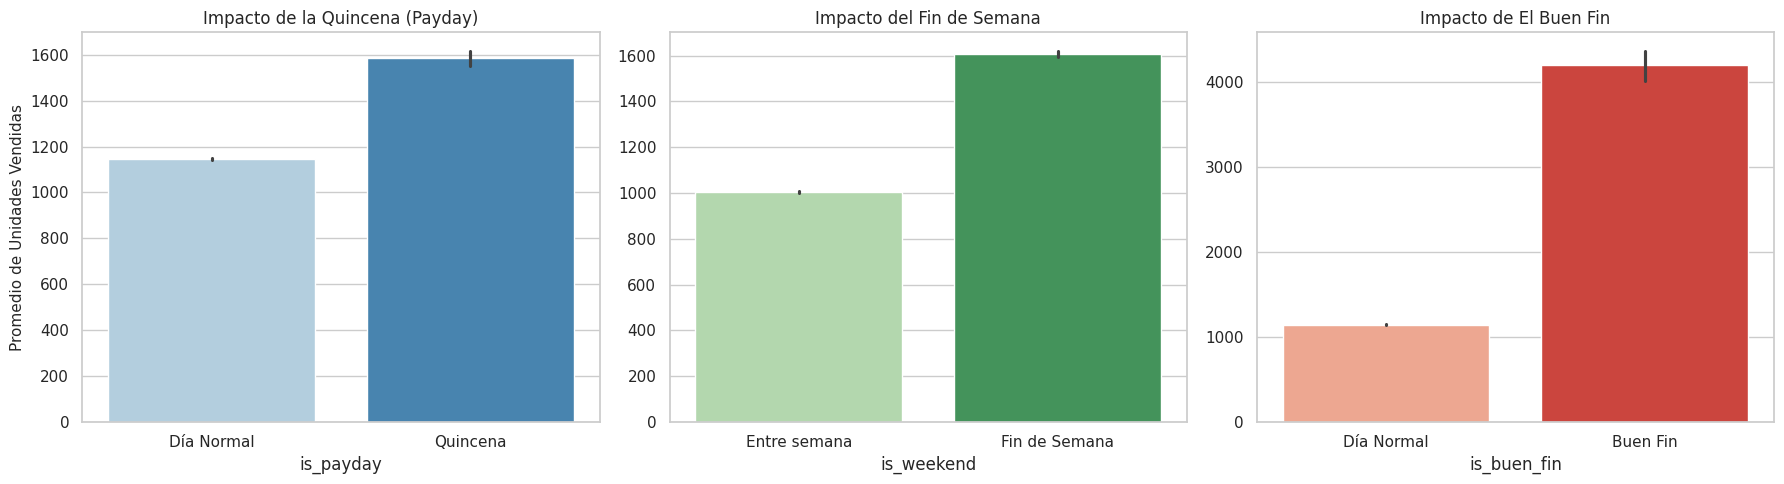


🎯 INSIGHTS DE NEGOCIO (Validación de Features)
-> Efectivamente, existe una variación clara en las ventas durante estos eventos.
-> Estas variables temporales serán los pilares (Features principales) de nuestro
   modelo de Machine Learning, ya que son 100% resilientes a fallas de red.


In [8]:
print("[INFO] Analizando el impacto de eventos de calendario en las ventas\n")

# Crear una figura con 3 subgráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica 1: Quincena (Payday)
sns.barplot(data=df_master, x='is_payday', y='units_sold', estimator='mean', ax=axes[0], palette='Blues')
axes[0].set_title('Impacto de la Quincena (Payday)', fontsize=12)
axes[0].set_ylabel('Promedio de Unidades Vendidas', fontsize=11)
axes[0].set_xticklabels(['Día Normal', 'Quincena'])

# Gráfica 2: Fin de semana
sns.barplot(data=df_master, x='is_weekend', y='units_sold', estimator='mean', ax=axes[1], palette='Greens')
axes[1].set_title('Impacto del Fin de Semana', fontsize=12)
axes[1].set_ylabel('')
axes[1].set_xticklabels(['Entre semana', 'Fin de Semana'])

# Gráfica 3: Buen Fin
sns.barplot(data=df_master, x='is_buen_fin', y='units_sold', estimator='mean', ax=axes[2], palette='Reds')
axes[2].set_title('Impacto de El Buen Fin', fontsize=12)
axes[2].set_ylabel('')
axes[2].set_xticklabels(['Día Normal', 'Buen Fin'])

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("🎯 INSIGHTS DE NEGOCIO (Validación de Features)")
print("="*80)
print("-> Efectivamente, existe una variación clara en las ventas durante estos eventos.")
print("-> Estas variables temporales serán los pilares (Features principales) de nuestro")
print("   modelo de Machine Learning, ya que son 100% resilientes a fallas de red.")

## 2. Ingeniería de Características (Feature Engineering)
### 2.1 Imputación Lógica de Valores Nulos

Tras un análisis profundo, determinamos que la métrica actual `replenishment_signal` está contaminada por fallas del sistema (Nulos) y heurísticas de emergencia. No podemos usarla como variable predictora (Data Leakage).

Nuestro objetivo **no es** reemplazar el sistema logístico de reposición de Walmart, sino que nuestro modelo actúe como un **Sistema de Respaldo Predictivo**. Para este propósito, hemos seleccionado **LightGBM** por encima de otras opciones robustas (como Random Forest o XGBoost) por las siguientes razones técnicas:

*   **Eficiencia a gran escala:** A diferencia de XGBoost, LightGBM utiliza agrupamiento por histogramas y crecimiento basado en hojas (*leaf-wise*). Esto lo hace significativamente más rápido y ligero en memoria al procesar miles de transacciones diarias por tienda y categoría.
*   **Rendimiento en Retail:** LightGBM es el estándar de oro actual para pronóstico de demanda en retail (dominó por completo la competencia M5 de Walmart), superando ampliamente a Random Forest en la captura de patrones de series de tiempo.

De esta manera, cuando el sistema POS falle, el motor de reposición corporativo recibirá la predicción precisa de nuestro LightGBM para poder calcular sus envíos sin detener la cadena de suministro.

Para preparar el terreno y poder crear variables de contexto histórico (Lags/Medias Móviles) sin que la línea de tiempo se rompa, primero debemos imputar los huecos históricos en las ventas usando interpolación lineal temporal por tienda y categoría.

In [9]:
def imputar_nulos_pos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Recibe la Tabla Maestra y repara los nulos generados por apagones del POS
    usando interpolación lineal temporal por tienda y categoría.
    Además, elimina la 'replenishment_signal' para evitar Data Leakage.
    """
    print("[INFO] Ejecutando imputar_nulos_pos()")
    df_clean = df.copy()

    # Asegurarnos de que el dataframe esté ordenado por tiempo para que la interpolación tenga sentido
    df_clean = df_clean.sort_values(by=['store_id', 'category', 'date'])

    columnas_a_imputar = ['units_sold', 'amount_cash', 'avg_ticket']

    # 1. Imputación temporal (Interpolación) para no romper las futuras series de tiempo
    for col in columnas_a_imputar:
        df_clean[col] = df_clean.groupby(['store_id', 'category'])[col].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both')
        )
        # Fallback de seguridad por si una categoría completa es nula desde el inicio
        df_clean[col] = df_clean[col].fillna(0)

    # 2. Eliminación de la variable contaminada
    if 'replenishment_signal' in df_clean.columns:
        df_clean = df_clean.drop(columns=['replenishment_signal'])
        print("[INFO] 'replenishment_signal' eliminada correctamente para prevenir Data Leakage.")

    print("[INFO] Imputación completada exitosamente.")
    return df_clean

# ---------------------------------------------------------
# EJECUCIÓN EN EL ENTORNO DE PRUEBAS
# ---------------------------------------------------------
# Aplicamos la función a nuestro tablón
df_master = imputar_nulos_pos(df_master)

# Validación final: Todo debe salir en cero
print("\n[VALIDACIÓN] Conteo de nulos tras la limpieza:")
display(df_master[['units_sold', 'amount_cash', 'avg_ticket']].isnull().sum())

[INFO] Ejecutando imputar_nulos_pos()
[INFO] 'replenishment_signal' eliminada correctamente para prevenir Data Leakage.
[INFO] Imputación completada exitosamente.

[VALIDACIÓN] Conteo de nulos tras la limpieza:


,0
units_sold,0
amount_cash,0
avg_ticket,0


### 2.2 Ingeniería de Variables Temporales (Feature Engineering)

Para que nuestro modelo de aprendizaje global (LightGBM) pueda capturar la estacionalidad y las tendencias de demanda, necesitamos traducir la columna `date` en variables que el algoritmo pueda procesar.

Construiremos tres dimensiones de tiempo por cada combinación de tienda y categoría:
1. **Calendario:** Extracción de día de la semana, mes y banderas de fin de semana.
2. **Rezagos (Lags):** Ventas de los últimos 1 y 7 días para capturar el comportamiento inmediato y semanal.
3. **Tendencias (Rolling Windows):** Promedio móvil de los últimos 7 días para suavizar el ruido diario y entender la inercia de compra.

*Nota:* Los agrupamientos (`groupby`) aseguran que no mezclemos el historial de la Tienda A con el de la Tienda B al desplazar los datos.

In [10]:
def crear_variables_tiempo(df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera variables de calendario, rezagos (lags) y medias móviles.
    Asume que el DataFrame ya pasó por la limpieza de nulos.
    """
    print("[INFO] Ejecutando crear_variables_tiempo()")
    df_feat = df.copy()

    # Asegurar que date sea formato datetime y ordenar la historia
    df_feat['date'] = pd.to_datetime(df_feat['date'])
    df_feat = df_feat.sort_values(by=['store_id', 'category', 'date'])

    # -------------------------------------------------------------
    # 1. Variables de Calendario
    # -------------------------------------------------------------
    df_feat['day_of_week'] = df_feat['date'].dt.dayofweek # Lunes=0, Domingo=6
    df_feat['is_weekend'] = df_feat['day_of_week'].isin([5, 6]).astype(int)
    df_feat['day_of_month'] = df_feat['date'].dt.day
    df_feat['month'] = df_feat['date'].dt.month

    # -------------------------------------------------------------
    # 2. Variables Históricas (Lags y Medias Móviles)
    # -------------------------------------------------------------
    # Creamos un objeto groupby para no mezclar tiendas ni categorías
    grupos = df_feat.groupby(['store_id', 'category'])['units_sold']

    # Lags (Qué pasó hace 1 día y hace 7 días)
    df_feat['lag_1'] = grupos.shift(1)
    df_feat['lag_7'] = grupos.shift(7)

    # Media móvil (El promedio de los 7 días ANTERIORES)
    # Usamos shift(1) para no incluir el día de "hoy" (eso sería Data Leakage)
    df_feat['rolling_mean_7'] = grupos.transform(
        lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
    )

    # -------------------------------------------------------------
    # 3. Limpieza de Lags
    # -------------------------------------------------------------
    # Al hacer shift, los primeros días de la historia quedarán como Nulos.
    # Los rellenamos con 0 para que LightGBM no se queje.
    cols_hist = ['lag_1', 'lag_7', 'rolling_mean_7']
    df_feat[cols_hist] = df_feat[cols_hist].fillna(0)

    print("[INFO] Variables temporales creadas con éxito.")
    return df_feat

# ---------------------------------------------------------
# EJECUCIÓN EN EL ENTORNO DE PRUEBAS
# ---------------------------------------------------------
df_master = crear_variables_tiempo(df_master)

# Vistazo rápido a las nuevas columnas
display(df_master[['store_id', 'category', 'date', 'units_sold', 'lag_1', 'lag_7', 'rolling_mean_7', 'is_weekend']].head(10))

[INFO] Ejecutando crear_variables_tiempo()...
[INFO] Variables temporales creadas con éxito.


,store_id,category,date,units_sold,lag_1,lag_7,rolling_mean_7,is_weekend
0,STR_001,Abarrotes,2023-01-01,2299.0,0.0,0.0,0.000000,1
1,STR_001,Abarrotes,2023-01-02,3011.0,2299.0,0.0,2299.000000,0
2,STR_001,Abarrotes,2023-01-03,3652.0,3011.0,0.0,2655.000000,0
3,STR_001,Abarrotes,2023-01-04,4165.0,3652.0,0.0,2987.333333,0
4,STR_001,Abarrotes,2023-01-05,3553.0,4165.0,0.0,3281.750000,0
5,STR_001,Abarrotes,2023-01-06,5654.0,3553.0,0.0,3336.000000,0
6,STR_001,Abarrotes,2023-01-07,3314.0,5654.0,0.0,3722.333333,1
7,STR_001,Abarrotes,2023-01-08,3032.0,3314.0,2299.0,3664.000000,1
8,STR_001,Abarrotes,2023-01-09,2464.0,3032.0,3011.0,3768.714286,0
9,STR_001,Abarrotes,2023-01-10,3791.0,2464.0,3652.0,3690.571429,0


### 2.3 Selección de Variables y Prevención de Data Leakage

Para garantizar que nuestro modelo sea robusto y funcional en un entorno de producción real, debemos realizar una selección de características (Feature Selection) enfocada en prevenir el filtrado de información (*Data Leakage*).

**El problema:** Columnas como `amount_cash` y `avg_ticket` ocurren de manera simultánea a nuestra variable objetivo (`units_sold`). Si intentamos predecir la demanda de "mañana", es imposible conocer cuánto dinero en efectivo ingresará "mañana".

**La solución:** Eliminaremos estas variables transaccionales simultáneas del dataset de entrenamiento. Nuestro modelo LightGBM deberá aprender a predecir basándose **exclusivamente** en variables deterministas (calendario) y datos históricos (Lags y Medias Móviles), los cuales sí estarán disponibles al momento de emitir un pronóstico.

In [11]:
def seleccionar_variables(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filtra las columnas finales para el modelo, eliminando aquellas
    que causarían Data Leakage (variables transaccionales simultáneas).
    """
    print("[INFO] Ejecutando seleccionar_variables()...")
    df_final = df.copy()

    # Lista negra: Variables financieras que ocurren al mismo tiempo que la venta
    columnas_tramposas = ['amount_cash', 'avg_ticket', 'amount_total', 'amount_card']

    # Eliminación segura
    columnas_a_eliminar = [col for col in columnas_tramposas if col in df_final.columns]

    if columnas_a_eliminar:
        df_final = df_final.drop(columns=columnas_a_eliminar)
        print(f"[INFO] Columnas eliminadas por Data Leakage: {columnas_a_eliminar}")
    else:
        print("[INFO] No se encontraron columnas con Data Leakage.")

    print("[INFO] Selección de variables completada.")
    return df_final

# ---------------------------------------------------------
# EJECUCIÓN EN EL ENTORNO DE PRUEBAS
# ---------------------------------------------------------
df_master = seleccionar_variables(df_master)

# Validación final
print("\n[VALIDACIÓN] Columnas definitivas que entran al modelo:")
print(df_master.columns.tolist())

[INFO] Ejecutando seleccionar_variables()...
[INFO] Columnas eliminadas por Data Leakage: ['amount_cash', 'avg_ticket', 'amount_total', 'amount_card']
[INFO] Selección de variables completada.

[VALIDACIÓN] Columnas definitivas que entran al modelo:
['date', 'store_id', 'category', 'total_transactions', 'cash_transactions', 'card_transactions', 'units_sold', 'has_promotion', 'store_format', 'region', 'size_sqm', 'num_checkouts', 'opening_year', 'socioeconomic_level', 'has_pharmacy', 'has_fuel_station', 'day_of_week', 'day_name', 'week_of_year', 'month', 'year', 'quarter', 'season', 'is_holiday', 'holiday_name', 'is_payday', 'is_weekend', 'is_navidad_season', 'is_buen_fin', 'is_semana_santa', 'day_of_month', 'lag_1', 'lag_7', 'rolling_mean_7']


In [12]:
df_master

,date,store_id,category,total_transactions,cash_transactions,card_transactions,units_sold,has_promotion,store_format,region,...,holiday_name,is_payday,is_weekend,is_navidad_season,is_buen_fin,is_semana_santa,day_of_month,lag_1,lag_7,rolling_mean_7
0,2023-01-01,STR_001,Abarrotes,833,NaN,326,2299.0,0,Supercenter,Norte,...,Año Nuevo,False,1,True,False,False,1,0.0,0.0,0.000000
1,2023-01-02,STR_001,Abarrotes,1298,750.0,548,3011.0,0,Supercenter,Norte,...,NaN,False,0,True,False,False,2,2299.0,0.0,2299.000000
2,2023-01-03,STR_001,Abarrotes,1614,931.0,683,3652.0,0,Supercenter,Norte,...,NaN,False,0,True,False,False,3,3011.0,0.0,2655.000000
3,2023-01-04,STR_001,Abarrotes,1726,972.0,754,4165.0,0,Supercenter,Norte,...,NaN,False,0,True,False,False,4,3652.0,0.0,2987.333333
4,2023-01-05,STR_001,Abarrotes,2159,1028.0,675,3553.0,1,Supercenter,Norte,...,NaN,False,0,True,False,False,5,4165.0,0.0,3281.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203953,2024-02-25,STR_080,Ropa,208,80.0,128,343.0,0,Express,Norte,...,NaN,False,1,False,False,False,25,460.0,490.0,321.571429
203954,2024-02-26,STR_080,Ropa,120,54.0,66,321.0,0,Express,Norte,...,NaN,False,0,False,False,False,26,343.0,276.0,300.571429
203955,2024-02-27,STR_080,Ropa,101,NaN,59,206.0,0,Express,Norte,...,NaN,False,0,False,False,False,27,321.0,305.0,307.000000
203956,2024-02-28,STR_080,Ropa,146,53.0,93,242.0,0,Express,Norte,...,NaN,False,0,False,False,False,28,206.0,270.0,292.857143


## 3. Entrenamiento y MLOps
### 3.1 Setup de MLflow y Estrategia de Validación Temporal
### 3.2 Establecimiento del Modelo Baseline (Marca a Vencer)

Para evaluar nuestros modelos evitamos la selección aleatoria tradicional (*shuffling*), la cual filtraría información del futuro hacia el pasado. En su lugar, aplicamos un **Split Temporal** separando los últimos **30 días** del historial como conjunto de validación (`val_df`). Esto simula con precisión el horizonte operativo mensual de planificación de inventarios en retail.

Además, iniciamos **MLflow** para el registro sistemático de nuestros experimentos. Antes de construir modelos más complejos, calculamos el rendimiento de un **Modelo Baseline (Pronóstico Ingenuo)** basado en la Media Móvil de 7 días (`rolling_mean_7`). Este valor establece la barrera de error (RMSE y MAE) que LightGBM deberá superar obligatoriamente para justificar su implementación en producción.

In [13]:
# Instalación e importación de dependencias para MLOps
!pip install -q mlflow

import mlflow
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------------------------------------------------------------
# 1. Configuración del Experimento en MLflow
# -------------------------------------------------------------
mlflow.set_experiment("Walmart_Demand_Forecasting")

# -------------------------------------------------------------
# 2. Split Temporal (Ventana de Validación de 30 Días)
# -------------------------------------------------------------
max_date = df_master['date'].max()
split_date = max_date - pd.Timedelta(days=30)

train_df = df_master[df_master['date'] <= split_date].copy()
val_df = df_master[df_master['date'] > split_date].copy()

print(f"[INFO] Fecha máxima en dataset: {max_date.strftime('%Y-%m-%d')}")
print(f"[INFO] Fecha de corte para validación: {split_date.strftime('%Y-%m-%d')}")
print(f"      - Registros Entrenamiento (Train): {len(train_df):,}")
print(f"      - Registros Validación (30 días):  {len(val_df):,}")

# -------------------------------------------------------------
# 3. Evaluación del Modelo Baseline (Pronóstico Ingenuo)
# -------------------------------------------------------------
# Usamos 'rolling_mean_7' como estimación básica de ventas
y_true = val_df['units_sold']
y_pred_baseline = val_df['rolling_mean_7']

# Cálculo de Métricas Oficiales
rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred_baseline))
mae_baseline = mean_absolute_error(y_true, y_pred_baseline)

# -------------------------------------------------------------
# 4. Registro del Experimento Baseline en MLflow
# -------------------------------------------------------------
with mlflow.start_run(run_name="00_Baseline_RollingMean7"):
    mlflow.log_param("model_type", "Baseline_Naive")
    mlflow.log_param("baseline_feature", "rolling_mean_7")
    mlflow.log_param("validation_days", 30)

    mlflow.log_metric("rmse", rmse_baseline)
    mlflow.log_metric("mae", mae_baseline)

print("\n" + "="*55)
print("📊 RESULTADOS DEL MODELO BASELINE (A VENCER EN FASE 3.3)")
print("="*55)
print(f"RMSE (Error Cuadrático Medio): {rmse_baseline:.4f}")
print(f"MAE  (Error Absoluto Medio):   {mae_baseline:.4f}")
print("="*55)
print("[INFO] Experimento registrado exitosamente en MLflow.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

2026/07/28 16:03:45 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/28 16:03:45 INFO mlflow.store.db.utils: Updating database tables
2026/07/28 16:03:47 INFO mlflow.tracking.fluent: Experiment with name 'Walmart_Demand_Forecasting' does not exist. Creating a new experiment.


[INFO] Fecha máxima en dataset: 2024-02-29
[INFO] Fecha de corte para validación: 2024-01-30
      - Registros Entrenamiento (Train): 189,576
      - Registros Validación (30 días):  14,382

📊 RESULTADOS DEL MODELO BASELINE (A VENCER EN FASE 3.3)
RMSE (Error Cuadrático Medio): 497.4351
MAE  (Error Absoluto Medio):   312.8821
[INFO] Experimento registrado exitosamente en MLflow.


### 3.3 Modelado Inicial con LightGBM (Modelo Global)

En este paso entrenamos nuestro primer modelo de Gradient Boosting utilizando **LightGBM**. A diferencia de los modelos tradicionales, utilizaremos un **enfoque global**: un solo modelo aprenderá de todas las tiendas y categorías simultáneamente.

**Puntos clave de la configuración:**
* **Manejo Nativo de Categóricas:** Convertimos `store_id` y `category` al tipo `category` de pandas. LightGBM aplicará un algoritmo basado en particiones de histograma (*Fisher's exact test*) en lugar de inflar la memoria con *One-Hot Encoding*.
* **Feature Matrix:** Excluimos la columna `date` y la variable objetivo `units_sold` de las matrices de entrenamiento ($X$).
* **MLflow Tracking:** Registramos los hiperparámetros iniciales y el rendimiento (RMSE/MAE) para comparar formalmente la reducción de error frente al Baseline.

In [18]:
import lightgbm as lgb

# -------------------------------------------------------------
# 1. Conversión Dinámica de Categóricas y Preparación de Matrices
# -------------------------------------------------------------
# Columnas que NO entran al modelo
cols_no_features = ['date', 'units_sold']

# Detectar automáticamente TODAS las columnas de tipo texto (object)
object_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print(f"[INFO] Columnas de texto detectadas para conversión: {object_cols}")

# Convertirlas a tipo 'category' en ambos conjuntos
for col in object_cols:
    train_df[col] = train_df[col].astype('category')
    val_df[col] = val_df[col].astype('category')

# Definir la lista final de predictores (X)
features = [col for col in train_df.columns if col not in cols_no_features]

X_train, y_train = train_df[features], train_df['units_sold']
X_val, y_val = val_df[features], val_df['units_sold']

print(f"[INFO] Total de variables de entrada ({len(features)}): {features}")

# -------------------------------------------------------------
# 2. Configuración y Entrenamiento del Modelo LightGBM
# -------------------------------------------------------------
params_base = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_estimators': 100,
    'learning_rate': 0.1,
    'random_state': 42,
    'verbose': -1
}

model_lgb = lgb.LGBMRegressor(**params_base)
model_lgb.fit(X_train, y_train)

# -------------------------------------------------------------
# 3. Predicción y Evaluación
# -------------------------------------------------------------
y_pred_lgb = model_lgb.predict(X_val)

# Regla de negocio: Forzamos a que las ventas no sean negativas
y_pred_lgb = np.clip(y_pred_lgb, a_min=0, a_max=None)

rmse_lgb = np.sqrt(mean_squared_error(y_val, y_pred_lgb))
mae_lgb = mean_absolute_error(y_val, y_pred_lgb)

# -------------------------------------------------------------
# 4. Registro del Experimento en MLflow
# -------------------------------------------------------------
with mlflow.start_run(run_name="01_LightGBM_Default"):
    mlflow.log_params(params_base)
    mlflow.log_metric("rmse", rmse_lgb)
    mlflow.log_metric("mae", mae_lgb)

    # Mejora porcentual vs Baseline
    mejora_rmse = ((rmse_baseline - rmse_lgb) / rmse_baseline) * 100
    mlflow.log_metric("improvement_vs_baseline_pct", mejora_rmse)

# -------------------------------------------------------------
# 5. Reporte Comparativo
# -------------------------------------------------------------
print("\n" + "="*60)
print("⚔️ COMPARATIVA DE RENDIMIENTO: BASELINE vs LIGHTGBM")
print("="*60)
print(f"Baseline RMSE: {rmse_baseline:.4f}  |  MAE: {mae_baseline:.4f}")
print(f"LightGBM RMSE: {rmse_lgb:.4f}  |  MAE: {mae_lgb:.4f}")
print("-"*60)
print(f"🚀 Mejora en RMSE: {mejora_rmse:.2f}% de reducción de error.")
print("="*60)

[INFO] Columnas de texto detectadas para conversión: []
[INFO] Total de variables de entrada (32): ['store_id', 'category', 'total_transactions', 'cash_transactions', 'card_transactions', 'has_promotion', 'store_format', 'region', 'size_sqm', 'num_checkouts', 'opening_year', 'socioeconomic_level', 'has_pharmacy', 'has_fuel_station', 'day_of_week', 'day_name', 'week_of_year', 'month', 'year', 'quarter', 'season', 'is_holiday', 'holiday_name', 'is_payday', 'is_weekend', 'is_navidad_season', 'is_buen_fin', 'is_semana_santa', 'day_of_month', 'lag_1', 'lag_7', 'rolling_mean_7']

⚔️ COMPARATIVA DE RENDIMIENTO: BASELINE vs LIGHTGBM
Baseline RMSE: 497.4351  |  MAE: 312.8821
LightGBM RMSE: 312.5074  |  MAE: 204.1776
------------------------------------------------------------
🚀 Mejora en RMSE: 37.18% de reducción de error.


> ⚠️ **Nota Arquitectónica sobre el Horizonte de Predicción (Forecasting Horizon)**
>
> El siguiente modelo LightGBM está configurado bajo el supuesto de negocio de **Inferencia Batch Diaria** (Pronóstico de 1 paso o *1-step ahead*). Al utilizar variables de rezago (`lag_1`), el modelo asume que en producción se ejecutará cada noche, teniendo acceso a las ventas reales del día inmediatamente anterior.
>
> **Consideración para Producción (Multi-step Forecast):**
> Si el negocio requiriera proyectar un horizonte continuo de 30 días (sin conocer las ventas intermedias), este enfoque directo generaría *Data Leakage* temporal durante la validación. Para un pase a producción real con horizonte extendido, la arquitectura debe evolucionar hacia un **Pronóstico Autoregresivo (Recursivo)**. En ese escenario, se recomendaría envolver este estimador de LightGBM con librerías especializadas como `skforecast` o `mlforecast` para automatizar la actualización dinámica de los *lags* iteración por iteración.

🔍 TABLA COMPARATIVA: Muestra aleatoria de predicciones


,date,store_id,category,real_units,pred_baseline,pred_lightgbm,error_baseline,error_lightgbm
176318,2024-02-15,STR_070,Abarrotes,820.0,1021.428571,1180.31,201.428571,360.31
62459,2024-02-14,STR_025,Cuidado_Personal,1055.0,1149.571429,1055.43,94.571429,0.43
189077,2024-02-24,STR_075,Abarrotes,2039.0,980.428571,1506.76,1058.571429,532.24
170381,2024-02-28,STR_067,Hogar,144.0,230.142857,229.42,86.142857,85.42
66273,2024-02-03,STR_026,Ropa,364.0,502.571429,503.76,138.571429,139.76
120259,2024-02-26,STR_048,Abarrotes,820.0,1797.142857,1105.17,977.142857,285.17
192891,2024-02-13,STR_076,Electronica,64.0,125.571429,110.58,61.571429,46.58
54807,2024-02-12,STR_022,Cuidado_Personal,635.0,915.714286,791.66,280.714286,156.66
175460,2024-02-07,STR_069,Hogar,470.0,439.857143,343.39,30.142857,126.61
125776,2024-02-18,STR_050,Bebidas,858.0,1610.142857,1355.96,752.142857,497.96


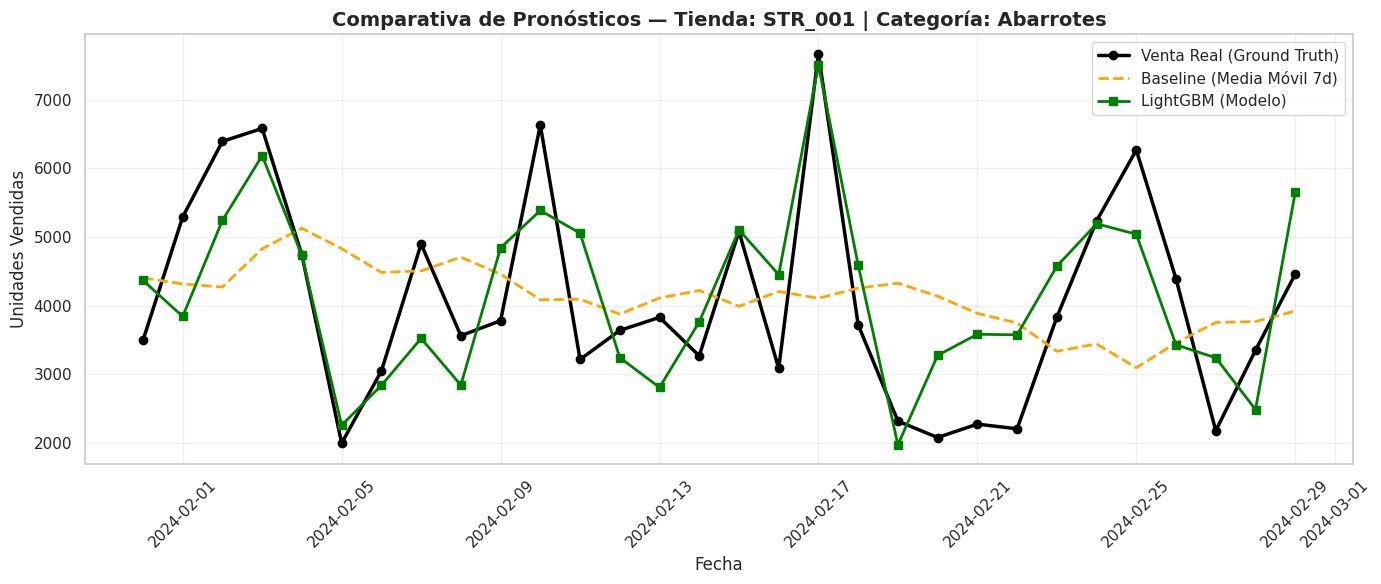

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# 1. Crear DataFrame comparativo de resultados
# -------------------------------------------------------------
df_resultados = val_df[['date', 'store_id', 'category', 'units_sold', 'rolling_mean_7']].copy()
df_resultados.rename(columns={'units_sold': 'real_units', 'rolling_mean_7': 'pred_baseline'}, inplace=True)

# Agregar la predicción de LightGBM
df_resultados['pred_lightgbm'] = np.round(y_pred_lgb, 2)

# Calcular errores absolutos fila por fila
df_resultados['error_baseline'] = np.abs(df_resultados['real_units'] - df_resultados['pred_baseline'])
df_resultados['error_lightgbm'] = np.abs(df_resultados['real_units'] - df_resultados['pred_lightgbm'])

print("🔍 TABLA COMPARATIVA: Muestra aleatoria de predicciones")
display(df_resultados.sample(10, random_state=42))

# -------------------------------------------------------------
# 2. Visualización de Series de Tiempo (Tienda y Categoría Específica)
# -------------------------------------------------------------
# Tomamos una combinación de tienda y categoría para ver la gráfica
tienda_ejemplo = df_resultados['store_id'].iloc[0]
cat_ejemplo = df_resultados['category'].iloc[0]

df_plot = df_resultados[(df_resultados['store_id'] == tienda_ejemplo) &
                       (df_resultados['category'] == cat_ejemplo)].sort_values('date')

plt.figure(figsize=(14, 6))
plt.plot(df_plot['date'], df_plot['real_units'], label='Venta Real (Ground Truth)', color='black', linewidth=2.5, marker='o')
plt.plot(df_plot['date'], df_plot['pred_baseline'], label='Baseline (Media Móvil 7d)', color='orange', linestyle='--', linewidth=2)
plt.plot(df_plot['date'], df_plot['pred_lightgbm'], label='LightGBM (Modelo)', color='green', linewidth=2, marker='s')

plt.title(f'Comparativa de Pronósticos — Tienda: {tienda_ejemplo} | Categoría: {cat_ejemplo}', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Unidades Vendidas')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Experimento de Validación: Imputación Lineal vs. Reconstrucción Predictiva

**Pregunta de Investigación:**
*¿La imputación lineal del Paso 2.1 es suficiente para estimar la demanda en días de apagón del POS, o el modelo LightGBM aporta un valor predictivo superior sobre el parche histórico?*

**Metodología (Experimento de Nulos Sintéticos):**
Para responder sin caer en especulaciones, se diseñó una prueba de control en el conjunto de validación:
1. Se seleccionó una ventana de 5 días con datos reales de ventas y se forzó una "caída de POS sintética" (eliminando los datos a propósito).
2. Se reconstruyeron los datos faltantes mediante **Interpolación Lineal** (parche geométrico cioso).
3. Se generó el pronóstico para esa misma ventana con **LightGBM** (patrón contextual por día de la semana e inercia).
4. Se evaluaron ambos enfoques contra la **Venta Real oculta**.

**Resultados Obtenidos:**
* **Error RMSE Interpolación Lineal:** `1532.64`
* **Error RMSE LightGBM:** `1128.06`
* **Ganancia de Precisión:** `26.40%` de reducción de error en favor de LightGBM.

**Conclusión Operativa:**
La interpolación lineal cumple únicamente una función de saneamiento técnico inicial para no romper las variables de rezago (`lags`). Sin embargo, para efectos de reposición de inventario en días de falla del POS, **las predicciones de LightGBM deben utilizarse como la Fuente de Verdad**, ya que capturan la estacionalidad del negocio que una línea recta ignora por completo.

🧪 RESULTADOS DEL EXPERIMENTO EN DÍAS SIMULADOS SIN POS
Error RMSE Interpolación Lineal : 1532.6444
Error RMSE LightGBM             : 1128.0636
------------------------------------------------------------
🏆 GANADOR: LightGBM es un 26.40% MÁS PRECISO en días de apagón.


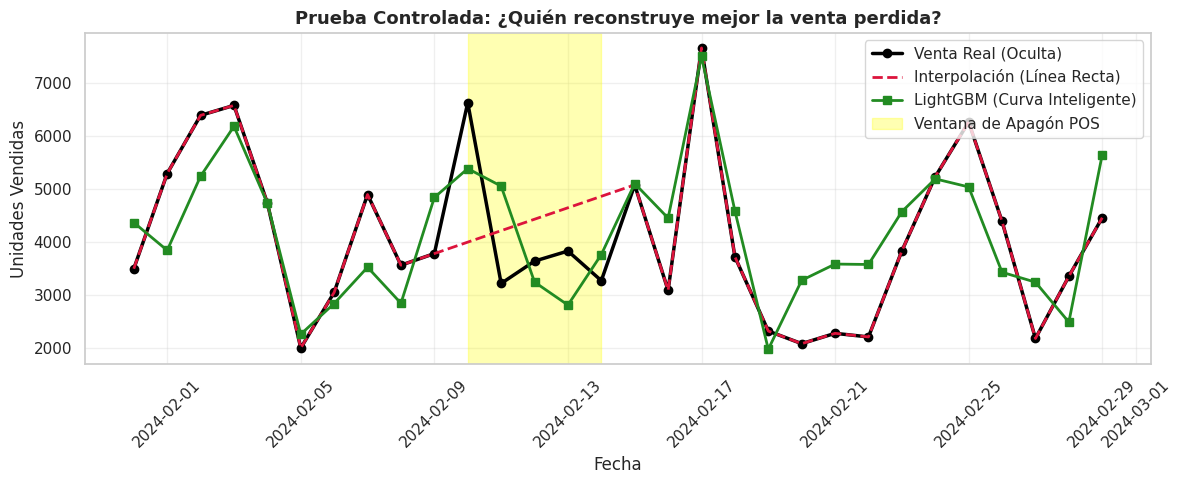

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------------------------------------------------------------
# EXPERIMENTO DE NULOS SINTÉTICOS (CAÍDA SIMULADA)
# -------------------------------------------------------------

# 1. Tomamos una tienda y categoría con datos reales completos
tienda_exp = val_df['store_id'].iloc[0]
cat_exp = val_df['category'].iloc[0]

df_sim = val_df[(val_df['store_id'] == tienda_exp) &
                (val_df['category'] == cat_exp)].sort_values('date').copy()

# Guardamos la VENTA REAL (Ground Truth)
df_sim['venta_real'] = df_sim['units_sold']

# 2. SIMULAR APAGÓN: Borramos 5 días a la mitad de la serie
inicio_apagon = 10
fin_apagon = 15
df_sim.iloc[inicio_apagon:fin_apagon, df_sim.columns.get_loc('units_sold')] = np.nan

# 3. MÉTODO A: Interpolación Lineal (Lo que hicimos en el paso 2.1)
df_sim['metodo_interpolacion'] = df_sim['units_sold'].interpolate(method='linear')

# 4. MÉTODO B: Predicción con LightGBM (Modelo Global)
df_exp_lgb = df_sim.copy()
for col in features:
    if str(X_train[col].dtype) == 'category':
        df_exp_lgb[col] = pd.Categorical(df_exp_lgb[col], categories=X_train[col].cat.categories)

df_sim['metodo_lightgbm'] = np.clip(model_lgb.predict(df_exp_lgb[features]), a_min=0, a_max=None)

# 5. EVALUACIÓN EXCLUSIVA EN LOS DÍAS DEL APAGÓN
dias_apagon = df_sim.iloc[inicio_apagon:fin_apagon]

rmse_interp = np.sqrt(mean_squared_error(dias_apagon['venta_real'], dias_apagon['metodo_interpolacion']))
rmse_lgb = np.sqrt(mean_squared_error(dias_apagon['venta_real'], dias_apagon['metodo_lightgbm']))

# -------------------------------------------------------------
# 6. RESULTADOS Y GRÁFICA
# -------------------------------------------------------------
print("="*60)
print("🧪 RESULTADOS DEL EXPERIMENTO EN DÍAS SIMULADOS SIN POS")
print("="*60)
print(f"Error RMSE Interpolación Lineal : {rmse_interp:.4f}")
print(f"Error RMSE LightGBM             : {rmse_lgb:.4f}")
print("-"*60)
if rmse_lgb < rmse_interp:
    mejora = ((rmse_interp - rmse_lgb) / rmse_interp) * 100
    print(f"🏆 GANADOR: LightGBM es un {mejora:.2f}% MÁS PRECISO en días de apagón.")
else:
    print("🏆 GANADOR: La Interpolación tuvo menor error en esta ventana.")
print("="*60)

# Graficar para ver el comportamiento
plt.figure(figsize=(12, 5))
plt.plot(df_sim['date'], df_sim['venta_real'], label='Venta Real (Oculta)', color='black', linewidth=2.5, marker='o')
plt.plot(df_sim['date'], df_sim['metodo_interpolacion'], label='Interpolación (Línea Recta)', color='crimson', linestyle='--', linewidth=2)
plt.plot(df_sim['date'], df_sim['metodo_lightgbm'], label='LightGBM (Curva Inteligente)', color='forestgreen', linewidth=2, marker='s')

# Sombra en el periodo del apagón
plt.axvspan(df_sim['date'].iloc[inicio_apagon], df_sim['date'].iloc[fin_apagon-1], color='yellow', alpha=0.3, label='Ventana de Apagón POS')

plt.title('Prueba Controlada: ¿Quién reconstruye mejor la venta perdida?', fontsize=13, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Unidades Vendidas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.4 Optimización de Hiperparámetros (Tuning)

Para mejorar el rendimiento del modelo base, realizaremos una búsqueda sobre un espacio de hiperparámetros clave de LightGBM:
* **learning_rate:** Controla qué tan rápido aprende el modelo. Valores bajos requieren más árboles pero suelen ser más precisos.
* **num_leaves:** Controla la complejidad de cada árbol.
* **max_depth:** Limita la profundidad para evitar el sobreajuste (*overfitting*).

**Nota Metodológica:** Se omiten técnicas tradicionales como K-Fold Cross Validation aleatorio para no violar el orden cronológico. En su lugar, cada combinación se entrena en el conjunto histórico y se evalúa estrictamente contra los últimos 30 días de validación.

In [19]:
from sklearn.model_selection import ParameterGrid

print("[INFO] Iniciando optimización de hiperparámetros...")

# 1. Definir el espacio de búsqueda (Grid)
param_grid = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1, 7],
    'n_estimators': [150] # Un poco más de árboles para compensar learning rates bajos
}

grid = ParameterGrid(param_grid)
best_rmse = float('inf')
best_params = None
best_model = None

# 2. Bucle de búsqueda respetando el Split Temporal
for params in grid:
    # Entrenar modelo con la combinación actual
    modelo_temp = lgb.LGBMRegressor(
        objective='regression',
        metric='rmse',
        boosting_type='gbdt',
        random_state=42,
        verbose=-1,
        **params
    )

    modelo_temp.fit(X_train, y_train)

    # Predecir y evaluar
    preds_temp = np.clip(modelo_temp.predict(X_val), a_min=0, a_max=None)
    rmse_temp = np.sqrt(mean_squared_error(y_val, preds_temp))

    # Guardar si es el mejor hasta ahora
    if rmse_temp < best_rmse:
        best_rmse = rmse_temp
        best_params = params
        best_model = modelo_temp

mae_tuneado = mean_absolute_error(y_val, np.clip(best_model.predict(X_val), a_min=0, a_max=None))

# 3. Registrar el modelo ganador en MLflow
with mlflow.start_run(run_name="02_LightGBM_Tuned"):
    mlflow.log_params(best_params)
    mlflow.log_metric("rmse", best_rmse)
    mlflow.log_metric("mae", mae_tuneado)

    mejora_vs_baseline = ((rmse_baseline - best_rmse) / rmse_baseline) * 100
    mlflow.log_metric("improvement_vs_baseline_pct", mejora_vs_baseline)

# 4. Resultados Finales
print("\n" + "="*60)
print("🏆 RESULTADOS DE LA OPTIMIZACIÓN (MEJOR MODELO)")
print("="*60)
print(f"Mejores Parámetros: {best_params}")
print("-"*60)
print(f"Baseline RMSE  : {rmse_baseline:.4f}")
print(f"LGBM Base RMSE : {rmse_lgb:.4f}")
print(f"LGBM Tuned RMSE: {best_rmse:.4f}")
print("-"*60)
print(f"🚀 Mejora total vs Baseline: {mejora_vs_baseline:.2f}%")
print("="*60)

[INFO] Iniciando optimización de hiperparámetros...

🏆 RESULTADOS DE LA OPTIMIZACIÓN (MEJOR MODELO)
Mejores Parámetros: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 150, 'num_leaves': 31}
------------------------------------------------------------
Baseline RMSE  : 497.4351
LGBM Base RMSE : 312.5074
LGBM Tuned RMSE: 311.8122
------------------------------------------------------------
🚀 Mejora total vs Baseline: 37.32%
